# 04 — Customer Segment Analysis
Revenue, profit, order frequency, and average sale value split by customer segment.

## Setup — Spark Session & Load HDFS Tables

In [1]:
import os, sys

os.environ["JAVA_HOME"]             = "/usr/local/java"
os.environ["SPARK_HOME"]            = "/usr/local/spark"
os.environ["HADOOP_CONF_DIR"]       = "/usr/local/hadoop/etc/hadoop"
os.environ["PYSPARK_PYTHON"]        = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.getActiveSession()
if spark is None:
    spark = (SparkSession.builder
        .appName("04 — Customer Segment Analysis")
        .master("spark://namenode:7077")
        .config("spark.sql.shuffle.partitions", "4")
        .getOrCreate())

spark.sparkContext.setLogLevel("WARN")

HDFS_BASE = "hdfs:///data"

def load_csv(name, renames):
    df = (spark.read
          .option("header", "true")
          .option("inferSchema", "true")
          .csv(f"{HDFS_BASE}/{name}.csv"))
    for old, new in renames.items():
        df = df.withColumnRenamed(old, new)
    df.createOrReplaceTempView(name)
    return df

load_csv("customers",   {"Customer ID":"customer_id","Customer Name":"customer_name","Segment":"segment"})
load_csv("orders",      {"Order ID":"order_id","Order Date":"order_date","Ship Date":"ship_date",
                          "Ship Mode":"ship_mode","Customer ID":"customer_id","Postal Code":"postal_code"})
load_csv("order_items", {"Row ID":"row_id","Order ID":"order_id","Product ID":"product_id",
                          "Sales":"sales","Quantity":"quantity","Discount":"discount","Profit":"profit"})
load_csv("products",    {"Product ID":"product_id","Product Name":"product_name",
                          "Category":"category","Sub-Category":"sub_category"})
load_csv("locations",   {"Postal Code":"postal_code","City":"city","State":"state",
                          "Country":"country","Region":"region"})

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

CHARTS_DIR = "/usr/local/hadoop/etc/hadoop/assessment-2/charts"
os.makedirs(CHARTS_DIR, exist_ok=True)
print("Ready.")


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/28 16:59:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
                                                                                

Ready.


## Query

In [2]:
df = spark.sql('''
    SELECT
        c.segment,
        COUNT(DISTINCT c.customer_id) AS num_customers,
        COUNT(DISTINCT o.order_id)    AS total_orders,
        ROUND(SUM(oi.sales),  2)      AS total_sales,
        ROUND(SUM(oi.profit), 2)      AS total_profit,
        ROUND(AVG(oi.sales),  2)      AS avg_item_value
    FROM customers c
    JOIN orders      o  ON c.customer_id = o.customer_id
    JOIN order_items oi ON o.order_id    = oi.order_id
    GROUP BY c.segment ORDER BY total_sales DESC
''').toPandas()
print(df)

       segment  num_customers  total_orders  total_sales  total_profit  \
0     Consumer            409          2586   1161401.34     134119.21   
1    Corporate            236          1514    706146.37      91979.13   
2  Home Office            148           909    429653.15      60298.68   

   avg_item_value  
0          223.73  
1          233.82  
2          240.97  


## Visualisation

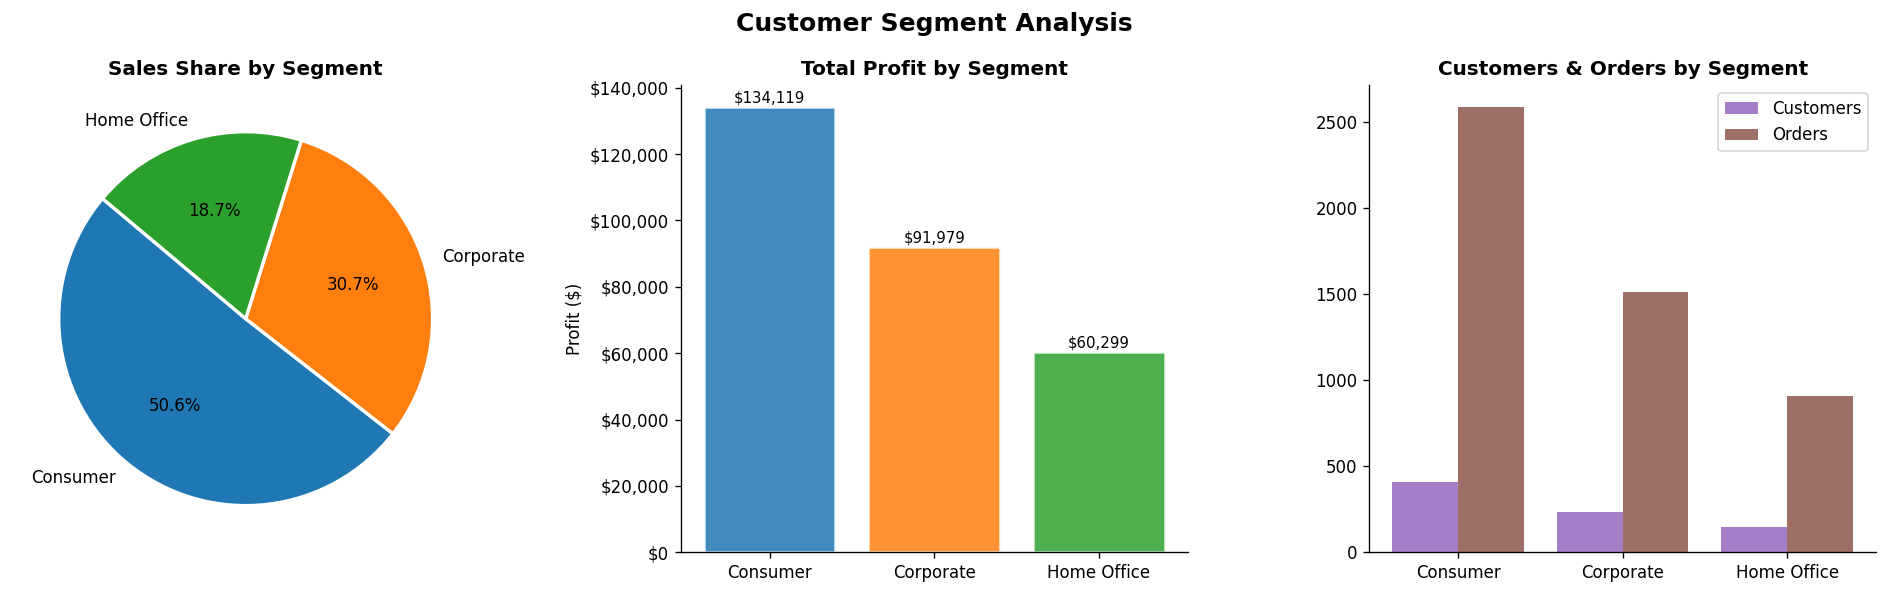

Chart saved to /usr/local/hadoop/etc/hadoop/assessment-2/charts/04_customer_segment.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ["#1f77b4","#ff7f0e","#2ca02c"]

axes[0].pie(df["total_sales"], labels=df["segment"], autopct="%1.1f%%",
            colors=colors, startangle=140, wedgeprops={"edgecolor":"white","linewidth":2})
axes[0].set_title("Sales Share by Segment", fontweight="bold")

axes[1].bar(df["segment"], df["total_profit"], color=colors, alpha=0.85, edgecolor="white", lw=1.5)
for i,(s,v) in enumerate(zip(df["segment"],df["total_profit"])):
    axes[1].text(i, v+max(df["total_profit"])*0.01, f"${v:,.0f}", ha="center", fontsize=9)
axes[1].set_title("Total Profit by Segment", fontweight="bold"); axes[1].set_ylabel("Profit ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}"))

x = range(len(df))
axes[2].bar([i-0.2 for i in x], df["num_customers"], 0.4, label="Customers", color="#9467bd", alpha=0.85)
axes[2].bar([i+0.2 for i in x], df["total_orders"],  0.4, label="Orders",    color="#8c564b", alpha=0.85)
axes[2].set_xticks(list(x)); axes[2].set_xticklabels(df["segment"])
axes[2].set_title("Customers & Orders by Segment", fontweight="bold"); axes[2].legend()

plt.suptitle("Customer Segment Analysis", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.savefig(f"{CHARTS_DIR}/04_customer_segment.png", bbox_inches="tight")
plt.show()
print(f"Chart saved to {CHARTS_DIR}/04_customer_segment.png")

## Stop Spark

In [4]:
spark.stop()
print("Spark session stopped.")

Spark session stopped.
